In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
print("Dataset shape:", df.shape)
print("\nTarget distribution (0=Malignant, 1=Benign):")
print(df['target'].value_counts())

Dataset shape: (569, 31)

Target distribution (0=Malignant, 1=Benign):
target
1    357
0    212
Name: count, dtype: int64


In [2]:
X = df.drop('target', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"\nSuccessfully scaled {X_scaled.shape[0]} samples with {X_scaled.shape[1]} features.")


Successfully scaled 569 samples with 30 features.


In [3]:
from sklearn.decomposition import PCA
pca = PCA(n_components=None, random_state=42)
pca.fit(X_scaled)
X_pca = pca.transform(X_scaled)
X_reconstructed = pca.inverse_transform(X_pca)
mse = np.mean((X_scaled - X_reconstructed)**2, axis=1)
df['reconstruction_error'] = mse
print("Reconstruction Error statistics:")
print(df.groupby('target')['reconstruction_error'].describe())

Reconstruction Error statistics:
        count          mean           std           min           25%  \
target                                                                  
0       212.0  3.381583e-30  4.159433e-30  2.052689e-31  1.176171e-30   
1       357.0  1.339464e-30  1.590187e-30  1.108012e-31  6.395825e-31   

                 50%           75%           max  
target                                            
0       2.090240e-30  4.073688e-30  3.374799e-29  
1       9.912466e-31  1.546862e-30  2.159761e-29  


In [4]:
from sklearn.ensemble import IsolationForest
contamination_rate = (df['target'] == 0).mean()
print(f"Using contamination rate: {contamination_rate:.4f}")
iso_forest = IsolationForest(n_estimators=100, 
                             contamination=contamination_rate, 
                             random_state=42)

iso_forest.fit(X_scaled)
anomaly_scores_if = iso_forest.decision_function(X_scaled)
df['isolation_forest_score'] = anomaly_scores_if
df['isolation_forest_prediction'] = iso_forest.predict(X_scaled)
print("\nIsolation Forest Score statistics:")
print(df.groupby('target')['isolation_forest_score'].describe())

Using contamination rate: 0.3726

Isolation Forest Score statistics:
        count      mean       std       min       25%       50%       75%  \
target                                                                      
0       212.0 -0.033107  0.060324 -0.259472 -0.054993 -0.018517  0.008425   
1       357.0  0.015888  0.042606 -0.237611  0.009069  0.029572  0.042088   

             max  
target            
0       0.049445  
1       0.061233  


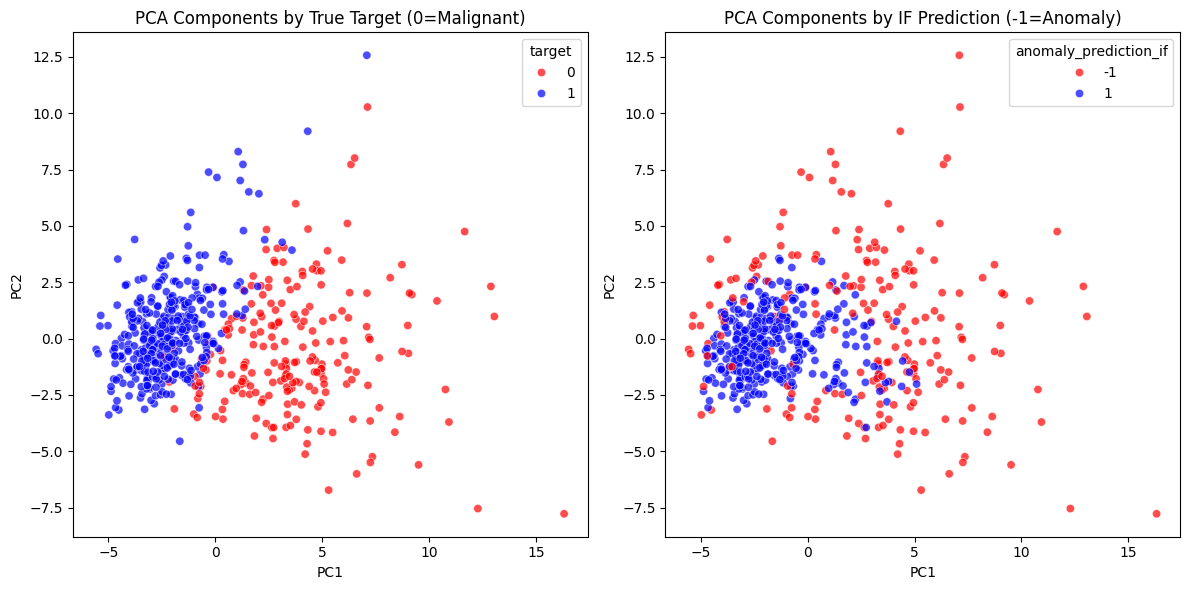

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
pca_df['target'] = df['target']
pca_df['anomaly_prediction_if'] = df['isolation_forest_prediction']
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(
    x='PC1', y='PC2', hue='target',
    data=pca_df, alpha=0.7,
    palette={0: 'red', 1: 'blue'}
)
plt.title('PCA Components by True Target (0=Malignant)')
plt.subplot(1, 2, 2)
sns.scatterplot(
    x='PC1', y='PC2', hue='anomaly_prediction_if',
    data=pca_df, alpha=0.7,
    palette={-1: 'red', 1: 'blue'}
)
plt.title('PCA Components by IF Prediction (-1=Anomaly)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_685521/253229569.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='reconstruction_error', data=df, palette={'0': 'red', '1': 'blue'})
/tmp/ipykernel_685521/253229569.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='isolation_forest_score', data=df, palette={'0': 'red', '1': 'blue'})


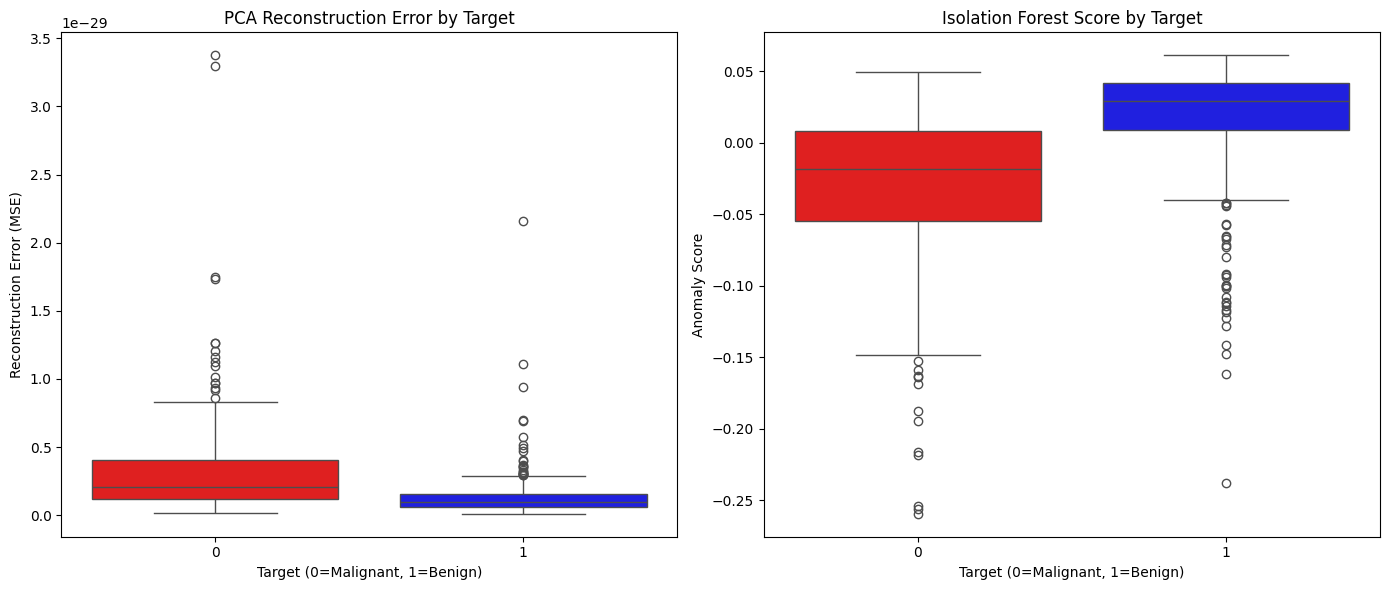

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='target', y='reconstruction_error', data=df, palette={'0': 'red', '1': 'blue'})
plt.title('PCA Reconstruction Error by Target')
plt.xlabel('Target (0=Malignant, 1=Benign)')
plt.ylabel('Reconstruction Error (MSE)')
plt.subplot(1, 2, 2)
sns.boxplot(x='target', y='isolation_forest_score', data=df, palette={'0': 'red', '1': 'blue'})
plt.title('Isolation Forest Score by Target')
plt.xlabel('Target (0=Malignant, 1=Benign)')
plt.ylabel('Anomaly Score')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
y_true = df['target']
y_pred_if = df['isolation_forest_prediction'].map({1: 1, -1: 0})

print("--- Isolation Forest Evaluation ---")
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_if))
print("\nClassification Report:")
print(classification_report(y_true, y_pred_if, target_names=['Malignant (0)', 'Benign (1)']))

--- Isolation Forest Evaluation ---
Confusion Matrix:
[[143  69]
 [ 69 288]]

Classification Report:
               precision    recall  f1-score   support

Malignant (0)       0.67      0.67      0.67       212
   Benign (1)       0.81      0.81      0.81       357

     accuracy                           0.76       569
    macro avg       0.74      0.74      0.74       569
 weighted avg       0.76      0.76      0.76       569



In [ ]:
threshold = df['reconstruction_error'].quantile(0.90)
y_pred_pca = (df['reconstruction_error'] < threshold).astype(int)

print(f"\n--- PCA Reconstruction Error Evaluation (Threshold: {threshold:.2e}) ---")
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_pca))
print("\nClassification Report:")
print(classification_report(y_true, y_pred_pca, target_names=['Malignant (0)', 'Benign (1)']))


--- PCA Reconstruction Error Evaluation (Threshold: 4.27e-30) ---
Confusion Matrix:
[[ 48 164]
 [  9 348]]

Classification Report:
               precision    recall  f1-score   support

Malignant (0)       0.84      0.23      0.36       212
   Benign (1)       0.68      0.97      0.80       357

     accuracy                           0.70       569
    macro avg       0.76      0.60      0.58       569
 weighted avg       0.74      0.70      0.64       569



--- Isolation Forest Evaluation ---
Confusion Matrix:


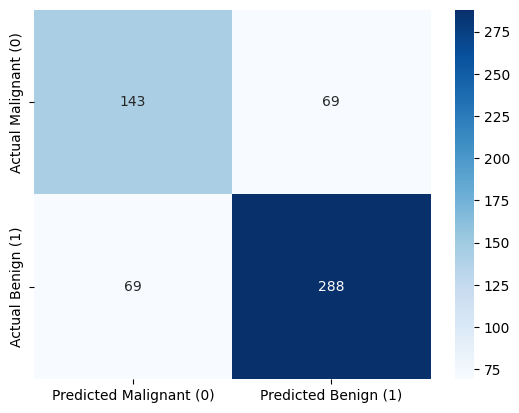


Classification Report:
               precision    recall  f1-score   support

Malignant (0)       0.67      0.67      0.67       212
   Benign (1)       0.81      0.81      0.81       357

     accuracy                           0.76       569
    macro avg       0.74      0.74      0.74       569
 weighted avg       0.76      0.76      0.76       569



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
y_true = df['target']
y_pred_if = df['isolation_forest_prediction'].map({1: 1, -1: 0})

print("--- Isolation Forest Evaluation ---")
print("Confusion Matrix:")
cm_if = confusion_matrix(y_true, y_pred_if)
sns.heatmap(cm_if, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Malignant (0)', 'Predicted Benign (1)'], 
            yticklabels=['Actual Malignant (0)', 'Actual Benign (1)'])
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred_if, target_names=['Malignant (0)', 'Benign (1)']))


--- PCA Reconstruction Error Evaluation (Threshold: 4.2674e-30) ---
Confusion Matrix:


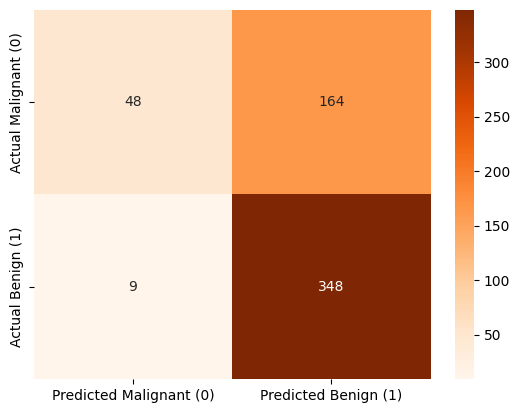


Classification Report:
               precision    recall  f1-score   support

Malignant (0)       0.84      0.23      0.36       212
   Benign (1)       0.68      0.97      0.80       357

     accuracy                           0.70       569
    macro avg       0.76      0.60      0.58       569
 weighted avg       0.74      0.70      0.64       569



In [ ]:
threshold = df['reconstruction_error'].quantile(0.90)
y_pred_pca = (df['reconstruction_error'] < threshold).astype(int)

print(f"\n--- PCA Reconstruction Error Evaluation (Threshold: {threshold:.4e}) ---")
print("Confusion Matrix:")
cm_pca = confusion_matrix(y_true, y_pred_pca)
sns.heatmap(cm_pca, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted Malignant (0)', 'Predicted Benign (1)'], 
            yticklabels=['Actual Malignant (0)', 'Actual Benign (1)'])
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred_pca, target_names=['Malignant (0)', 'Benign (1)']))